# Soft Protein Partition — Strategy & Visualization

This notebook visualizes how `registry_soft_split.csv` is constructed:

1. **Hard split** (baseline): entire protein clusters are atomically assigned to train/val/test
2. **Soft split** (new): proteins are sampled *within* each cluster in 70/15/15 proportion
3. **2D split matrix**: ligand chemical similarity × protein partition
4. **pChEMBL coverage**: which proteins have regression targets

**Data files used:**
- `data/uniprot_bipartite_cluster_labels.csv` — protein cluster assignments
- `training_data_full/registry_soft_split.csv` — soft-partition registry
- `training_data_full/registry_soft_split_regression.csv` — enriched with pChEMBL
- `training_data_full/registry_2d_split.csv` — original hard-split registry (for comparison)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

REPO = '/home/aoxu/projects/VLS-Benchmark-Dataset'
PARTITION_COLORS = {'train': '#4878CF', 'val': '#6ACC65', 'test': '#D65F5F'}
SPLIT_COLORS     = {'train': '#4878CF', 'test': '#D65F5F', 'decoy': '#AAAAAA'}

In [2]:
# Load cluster labels
clusters = pd.read_csv(f'{REPO}/data/uniprot_bipartite_cluster_labels.csv')
print('Cluster file shape:', clusters.shape)
print(clusters.head(3))

Cluster file shape: (837, 5)
  uniprot  cluster_bipartite_qcov_50  cluster_bipartite_qcov_70  \
0  O00141                        128                        101   
1  O00206                        117                        130   
2  O00238                        128                        101   

   cluster_bipartite_qcov_95  cluster_bipartite_qcov_100  
0                        143                         333  
1                        302                         319  
2                        143                         333  


In [3]:
# Load soft-split registry (sample for speed)
reg = pd.read_csv(f'{REPO}/training_data_full/registry_soft_split.csv', low_memory=False)
print(f'Registry: {len(reg):,} rows, {reg["uniprot_id"].nunique()} proteins')

# Work with actives only for most plots
actives = reg[reg['is_active'] == True].copy()
print(f'Actives:  {len(actives):,} rows')

Registry: 2,886,090 rows, 826 proteins
Actives:  831,030 rows


## 1. Cluster Size Distribution

The bipartite clustering (70% query coverage threshold) groups 826 proteins into 281 clusters.
Most clusters are singletons — they are forced entirely into train.

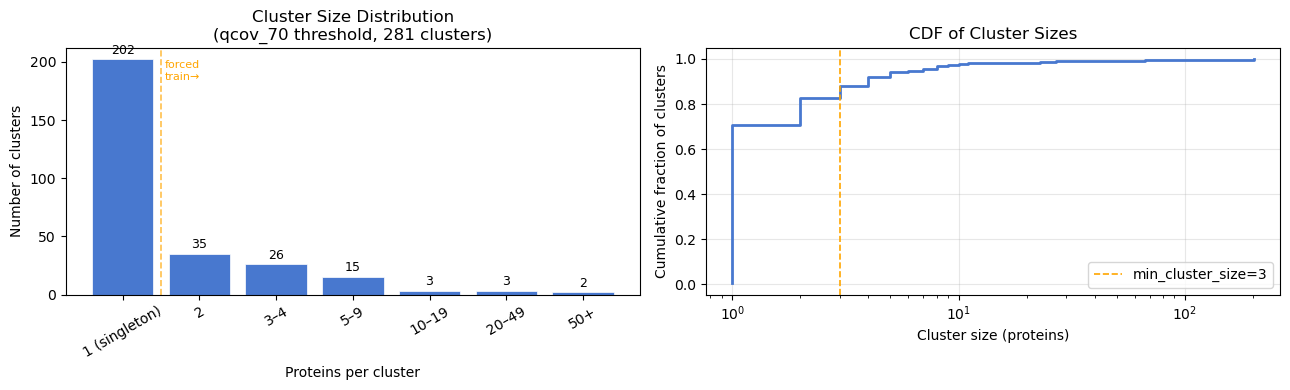

In [4]:
CLUSTER_COL = 'cluster_bipartite_qcov_70'
cluster_sizes = clusters.groupby(CLUSTER_COL)['uniprot'].count()

# Bin sizes
bins = [1, 2, 3, 5, 10, 20, 50, 300]
labels = ['1 (singleton)', '2', '3–4', '5–9', '10–19', '20–49', '50+']
counts = [((cluster_sizes >= lo) & (cluster_sizes < hi)).sum()
          for lo, hi in zip(bins, bins[1:])]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart of cluster size bins
ax = axes[0]
bars = ax.bar(labels, counts, color='#4878CF', edgecolor='white', linewidth=0.5)
ax.bar_label(bars, padding=2, fontsize=9)
ax.set_xlabel('Proteins per cluster')
ax.set_ylabel('Number of clusters')
ax.set_title('Cluster Size Distribution\n(qcov_70 threshold, 281 clusters)')
ax.tick_params(axis='x', rotation=30)

# Annotate: singletons → all train; others → split
ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(0.55, ax.get_ylim()[1]*0.95, 'forced\ntrain→', fontsize=8, color='orange', va='top')

# CDF of cluster sizes
ax2 = axes[1]
sorted_sizes = np.sort(cluster_sizes.values)
cdf = np.arange(1, len(sorted_sizes)+1) / len(sorted_sizes)
ax2.step(sorted_sizes, cdf, where='post', color='#4878CF', linewidth=2)
ax2.axvline(3, color='orange', linestyle='--', linewidth=1.2, label='min_cluster_size=3')
ax2.set_xlabel('Cluster size (proteins)')
ax2.set_ylabel('Cumulative fraction of clusters')
ax2.set_title('CDF of Cluster Sizes')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{REPO}/notebooks/figures/soft_split_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Hard Split vs Soft Split — Protein Assignment Cartoon

For a cluster with N proteins:
- **Hard split**: the entire cluster goes to ONE partition
- **Soft split**: proteins are sampled proportionally into train/val/test

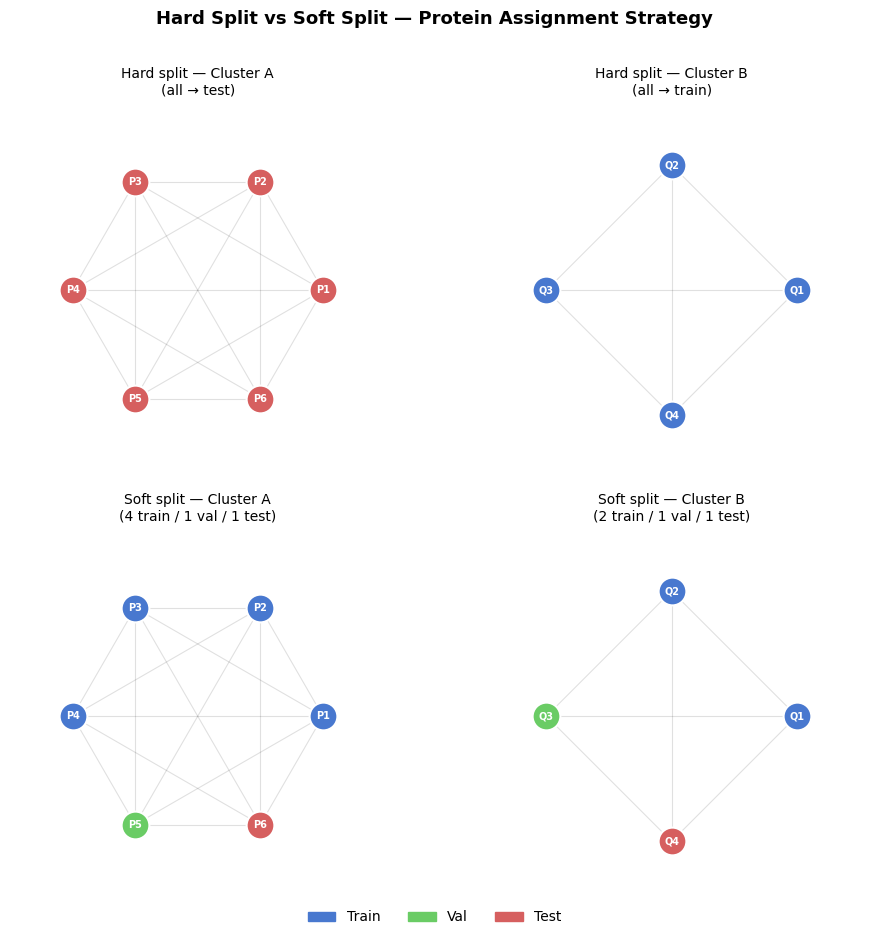

In [5]:
def draw_cluster_assignment(ax, proteins, assignment, title):
    """Draw a cluster of proteins coloured by partition."""
    n = len(proteins)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    r = 1.0
    for i, (prot, angle) in enumerate(zip(proteins, angles)):
        x, y = r * np.cos(angle), r * np.sin(angle)
        color = PARTITION_COLORS[assignment[i]]
        ax.scatter(x, y, s=400, c=color, zorder=3, edgecolors='white', linewidth=1.5)
        ax.annotate(prot, (x, y), ha='center', va='center', fontsize=7, color='white', fontweight='bold')
    # Draw edges (fully connected cluster)
    for i in range(n):
        for j in range(i+1, n):
            x1, y1 = r * np.cos(angles[i]), r * np.sin(angles[i])
            x2, y2 = r * np.cos(angles[j]), r * np.sin(angles[j])
            ax.plot([x1, x2], [y1, y2], 'k-', alpha=0.12, linewidth=0.8, zorder=1)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=10)


# Example: two clusters of different sizes
cluster_a = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
cluster_b = ['Q1', 'Q2', 'Q3', 'Q4']

hard_a = ['test'] * 6          # entire cluster → test
hard_b = ['train'] * 4         # entire cluster → train

soft_a = ['train', 'train', 'train', 'train', 'val', 'test']   # 4/1/1
soft_b = ['train', 'train', 'val', 'test']                      # 2/1/1

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

draw_cluster_assignment(axes[0, 0], cluster_a, hard_a, 'Hard split — Cluster A\n(all → test)')
draw_cluster_assignment(axes[0, 1], cluster_b, hard_b, 'Hard split — Cluster B\n(all → train)')
draw_cluster_assignment(axes[1, 0], cluster_a, soft_a, 'Soft split — Cluster A\n(4 train / 1 val / 1 test)')
draw_cluster_assignment(axes[1, 1], cluster_b, soft_b, 'Soft split — Cluster B\n(2 train / 1 val / 1 test)')

# Legend
legend_patches = [mpatches.Patch(color=c, label=p.capitalize())
                  for p, c in PARTITION_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Hard Split vs Soft Split — Protein Assignment Strategy', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{REPO}/notebooks/figures/soft_split_strategy_cartoon.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Actual Protein Partition Distribution

For all 826 registry proteins, broken down by cluster size.

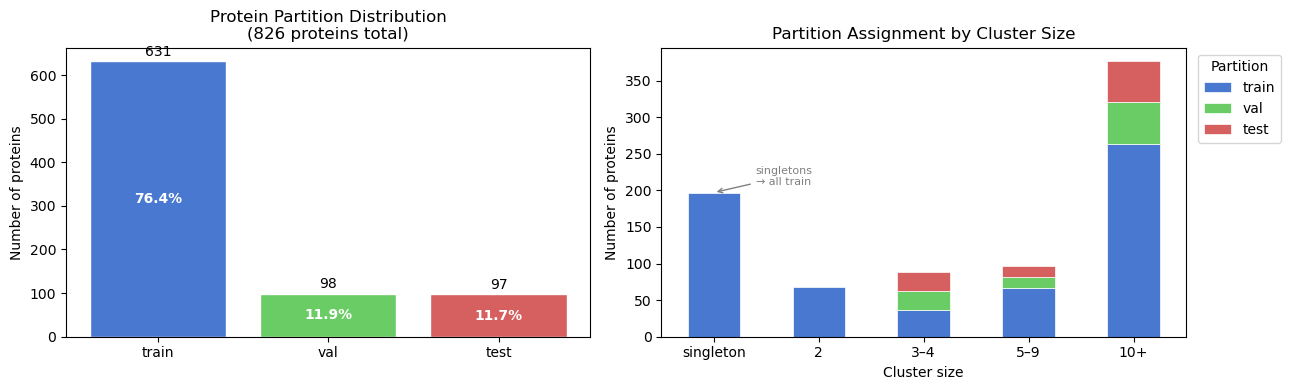

In [6]:
# Merge partition info back to cluster labels
protein_partitions = (
    actives[actives['split'] != 'decoy']
    .groupby('uniprot_id')['protein_partition']
    .first()
    .reset_index()
)
protein_info = protein_partitions.merge(
    clusters[['uniprot', CLUSTER_COL]].rename(columns={'uniprot': 'uniprot_id', CLUSTER_COL: 'cluster_id'}),
    on='uniprot_id', how='left'
)
cluster_size_map = clusters.groupby(CLUSTER_COL)['uniprot'].count().rename('cluster_size')
protein_info = protein_info.join(cluster_size_map, on='cluster_id')
protein_info['size_bin'] = pd.cut(
    protein_info['cluster_size'],
    bins=[0, 1, 2, 4, 9, 999],
    labels=['singleton', '2', '3–4', '5–9', '10+']
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overall counts per partition
ax = axes[0]
part_counts = protein_info['protein_partition'].value_counts().reindex(['train', 'val', 'test'])
bars = ax.bar(part_counts.index, part_counts.values,
              color=[PARTITION_COLORS[p] for p in part_counts.index],
              edgecolor='white')
ax.bar_label(bars, padding=2)
for bar, val in zip(bars, part_counts.values):
    pct = val / len(protein_info) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{pct:.1f}%', ha='center', va='center', color='white', fontweight='bold')
ax.set_ylabel('Number of proteins')
ax.set_title('Protein Partition Distribution\n(826 proteins total)')

# Right: stacked bar by cluster size bin
ax2 = axes[1]
pivot = protein_info.groupby(['size_bin', 'protein_partition']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=['train', 'val', 'test'])
pivot.plot(
    kind='bar', stacked=True, ax=ax2,
    color=[PARTITION_COLORS[p] for p in pivot.columns],
    edgecolor='white', linewidth=0.5
)
ax2.set_xlabel('Cluster size')
ax2.set_ylabel('Number of proteins')
ax2.set_title('Partition Assignment by Cluster Size')
ax2.tick_params(axis='x', rotation=0)
ax2.legend(title='Partition', bbox_to_anchor=(1.01, 1), loc='upper left')
ax2.annotate('singletons\n→ all train', xy=(0, pivot.loc['singleton', 'train']),
             xytext=(0.4, pivot.loc['singleton', 'train'] + 10),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f'{REPO}/notebooks/figures/soft_split_partition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 2D Split Matrix

The registry has two independent split axes:
- **Columns**: ligand Tanimoto similarity threshold (train compounds vs test compounds)
- **Rows**: protein partition (which proteins are in train/val/test)

This creates a grid of 6 cells. The standard training protocol uses:
- **Fit**: `protein=train × ligand=train`
- **Validate**: `protein=val × ligand=test`
- **Evaluate**: `protein=test × ligand=test`

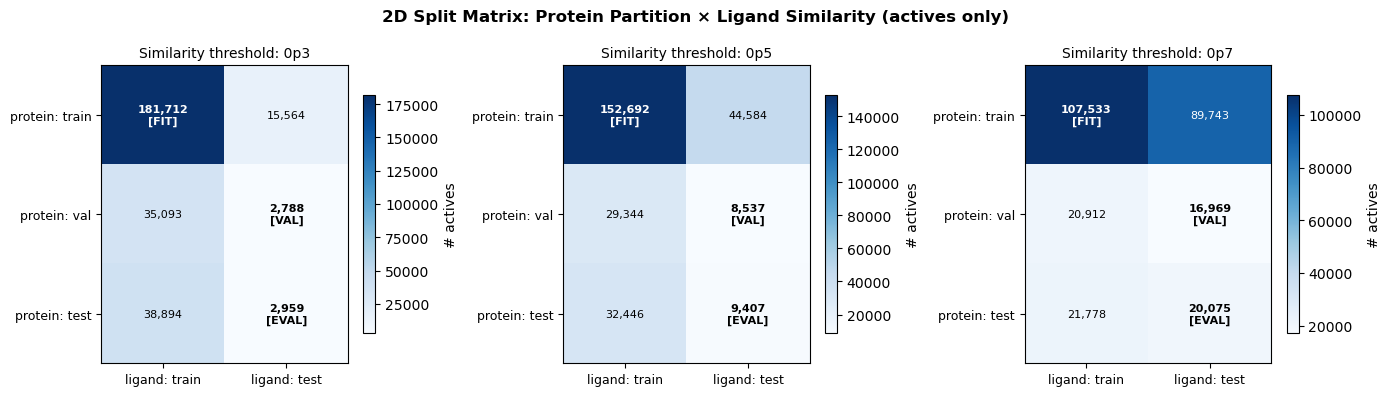

In [7]:
# Build 2D count matrix for each similarity threshold
thresholds = ['0p3', '0p5', '0p7']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, thresh in zip(axes, thresholds):
    sub = actives[actives['similarity_threshold'] == thresh]
    matrix = pd.crosstab(sub['protein_partition'], sub['split'])
    matrix = matrix.reindex(index=['train', 'val', 'test'], columns=['train', 'test'], fill_value=0)

    im = ax.imshow(matrix.values, cmap='Blues', aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['ligand: train', 'ligand: test'], fontsize=9)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['protein: train', 'protein: val', 'protein: test'], fontsize=9)
    ax.set_title(f'Similarity threshold: {thresh}', fontsize=10)

    for i in range(3):
        for j in range(2):
            val = matrix.values[i, j]
            role = ''
            if i == 0 and j == 0: role = '\n[FIT]'
            if i == 1 and j == 1: role = '\n[VAL]'
            if i == 2 and j == 1: role = '\n[EVAL]'
            text_color = 'white' if val > matrix.values.max() * 0.6 else 'black'
            ax.text(j, i, f'{val:,}{role}', ha='center', va='center',
                    fontsize=8, color=text_color, fontweight='bold' if role else 'normal')

    plt.colorbar(im, ax=ax, shrink=0.8, label='# actives')

fig.suptitle('2D Split Matrix: Protein Partition × Ligand Similarity (actives only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPO}/notebooks/figures/soft_split_2d_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Hard Split vs Soft Split — Cluster Fragmentation

In the hard split, every cluster has proteins in exactly 1 partition.  
In the soft split, 49/281 clusters have proteins spread across 2–3 partitions.

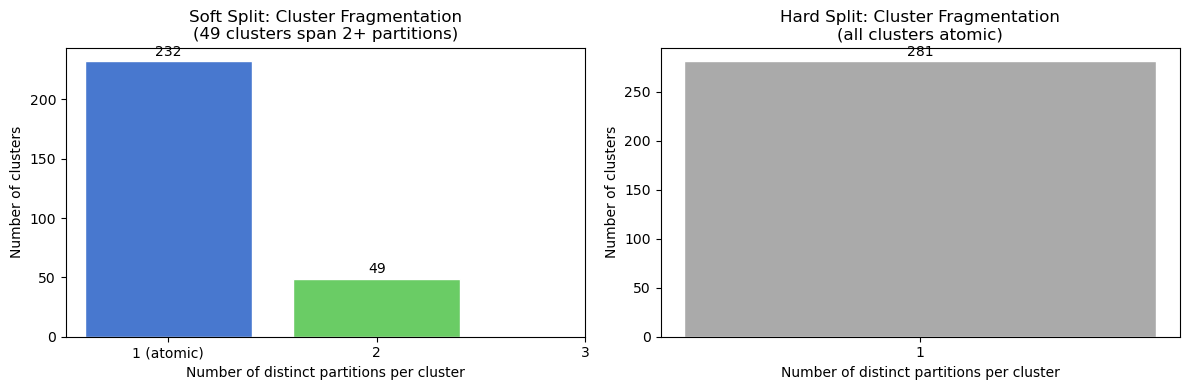

Soft split: 1 cluster size bins with >1 partition
protein_partition
1    232
3     49
Name: count, dtype: int64


In [8]:
# Soft split: partitions per cluster
soft_fragmentation = (
    protein_info.groupby('cluster_id')['protein_partition']
    .nunique()
    .value_counts()
    .sort_index()
)

# Hard split: load registry_2d_split.csv if it exists
import os
hard_reg_path = f'{REPO}/training_data_full/registry_2d_split.csv'
has_hard = os.path.exists(hard_reg_path)

fig, axes = plt.subplots(1, 2 if has_hard else 1, figsize=(12 if has_hard else 5, 4))
if not has_hard:
    axes = [axes]

ax = axes[0]
bars = ax.bar(soft_fragmentation.index.astype(str), soft_fragmentation.values,
              color=['#4878CF', '#6ACC65', '#D65F5F'][:len(soft_fragmentation)],
              edgecolor='white')
ax.bar_label(bars, padding=2)
ax.set_xlabel('Number of distinct partitions per cluster')
ax.set_ylabel('Number of clusters')
ax.set_title('Soft Split: Cluster Fragmentation\n(49 clusters span 2+ partitions)')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['1 (atomic)', '2', '3'])

if has_hard:
    hard_reg = pd.read_csv(hard_reg_path, usecols=['uniprot_id', 'protein_partition'], low_memory=False)
    hard_protein = hard_reg.groupby('uniprot_id')['protein_partition'].first().reset_index()
    hard_protein = hard_protein.merge(
        clusters[['uniprot', CLUSTER_COL]].rename(columns={'uniprot': 'uniprot_id', CLUSTER_COL: 'cluster_id'}),
        on='uniprot_id', how='left'
    )
    hard_fragmentation = (
        hard_protein.groupby('cluster_id')['protein_partition']
        .nunique()
        .value_counts()
        .sort_index()
    )
    ax2 = axes[1]
    bars2 = ax2.bar(hard_fragmentation.index.astype(str), hard_fragmentation.values,
                    color='#AAAAAA', edgecolor='white')
    ax2.bar_label(bars2, padding=2)
    ax2.set_xlabel('Number of distinct partitions per cluster')
    ax2.set_ylabel('Number of clusters')
    ax2.set_title('Hard Split: Cluster Fragmentation\n(all clusters atomic)')

plt.tight_layout()
plt.savefig(f'{REPO}/notebooks/figures/soft_split_cluster_fragmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Soft split: {(soft_fragmentation.index > 1).sum()} cluster size bins with >1 partition')
print(soft_fragmentation)

## 6. pChEMBL Coverage (regression registry)

After enrichment from `filtered_chembl_affinity.parquet`, 660K rows have pChEMBL values.

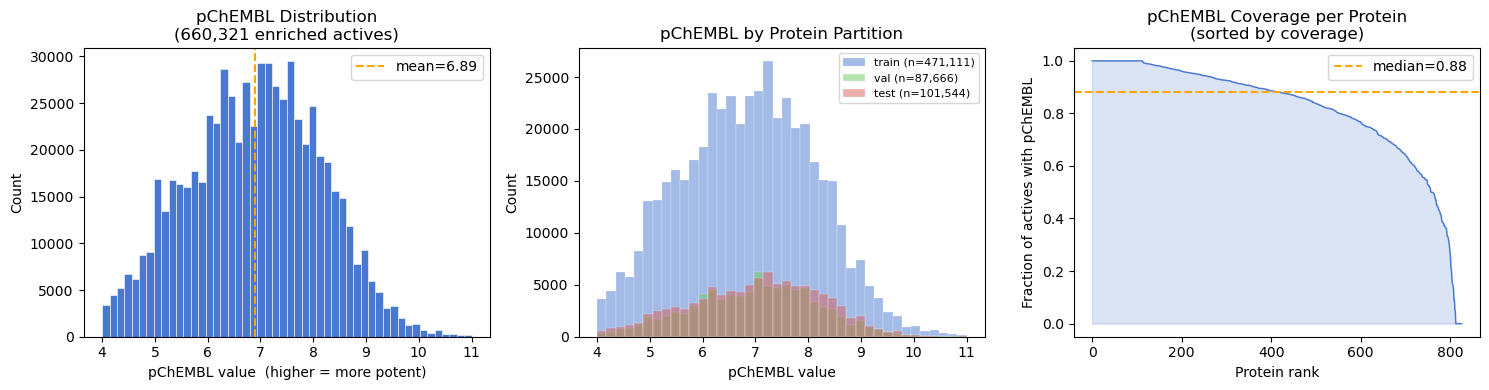

In [9]:
reg_path = f'{REPO}/training_data_full/registry_soft_split_regression.csv'
import os
if os.path.exists(reg_path):
    reg_r = pd.read_csv(reg_path, usecols=['uniprot_id', 'protein_partition', 'pchembl', 'is_active'],
                        low_memory=False)
    actives_r = reg_r[reg_r['is_active'] == True].copy()
    pchembl_valid = pd.to_numeric(actives_r['pchembl'], errors='coerce').dropna()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Distribution of pChEMBL values
    ax = axes[0]
    ax.hist(pchembl_valid, bins=50, color='#4878CF', edgecolor='white', linewidth=0.4)
    ax.axvline(pchembl_valid.mean(), color='orange', linestyle='--', label=f'mean={pchembl_valid.mean():.2f}')
    ax.set_xlabel('pChEMBL value  (higher = more potent)')
    ax.set_ylabel('Count')
    ax.set_title(f'pChEMBL Distribution\n({len(pchembl_valid):,} enriched actives)')
    ax.legend()

    # Per-partition pChEMBL distribution
    ax2 = axes[1]
    for part in ['train', 'val', 'test']:
        sub = pd.to_numeric(
            actives_r.loc[actives_r['protein_partition'] == part, 'pchembl'], errors='coerce'
        ).dropna()
        ax2.hist(sub, bins=40, alpha=0.5, label=f'{part} (n={len(sub):,})',
                 color=PARTITION_COLORS[part], edgecolor='white', linewidth=0.3)
    ax2.set_xlabel('pChEMBL value')
    ax2.set_ylabel('Count')
    ax2.set_title('pChEMBL by Protein Partition')
    ax2.legend(fontsize=8)

    # Coverage per protein (sorted)
    ax3 = axes[2]
    protein_coverage = (
        actives_r.groupby('uniprot_id')
        .apply(lambda g: pd.to_numeric(g['pchembl'], errors='coerce').notna().mean())
        .sort_values(ascending=False)
    )
    ax3.plot(range(len(protein_coverage)), protein_coverage.values, color='#4878CF', linewidth=1)
    ax3.fill_between(range(len(protein_coverage)), protein_coverage.values, alpha=0.2, color='#4878CF')
    ax3.axhline(protein_coverage.median(), color='orange', linestyle='--',
                label=f'median={protein_coverage.median():.2f}')
    ax3.set_xlabel('Protein rank')
    ax3.set_ylabel('Fraction of actives with pChEMBL')
    ax3.set_title('pChEMBL Coverage per Protein\n(sorted by coverage)')
    ax3.legend()

    plt.tight_layout()
    plt.savefig(f'{REPO}/notebooks/figures/soft_split_pchembl_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('registry_soft_split_regression.csv not found — run enrich_pchembl.py first')

## 7. Summary Table

In [10]:
rows = []
for part in ['train', 'val', 'test']:
    n_proteins = protein_info[protein_info['protein_partition'] == part]['uniprot_id'].nunique()
    sub_act = actives[actives['protein_partition'] == part]
    n_actives_07 = len(sub_act[sub_act['similarity_threshold'] == '0p7'])
    n_clusters = protein_info[protein_info['protein_partition'] == part]['cluster_id'].nunique()
    rows.append({
        'Partition': part,
        'Proteins': n_proteins,
        'Clusters represented': n_clusters,
        'Actives (0p7 threshold)': f'{n_actives_07:,}',
        'Protein %': f'{n_proteins/826*100:.1f}%',
    })

summary = pd.DataFrame(rows).set_index('Partition')
print('=== Soft Split Summary ===')
print(summary.to_string())
print()
print(f'Total clusters with proteins in 2+ partitions: {int((soft_fragmentation.index > 1).sum())} clusters')
print(f'Registry rows: {len(reg):,}')
print(f'Columns: {list(reg.columns)}')

=== Soft Split Summary ===
           Proteins  Clusters represented Actives (0p7 threshold) Protein %
Partition                                                                  
train           631                   281                 197,276     76.4%
val              98                    49                  37,881     11.9%
test             97                    49                  41,853     11.7%

Total clusters with proteins in 2+ partitions: 1 clusters
Registry rows: 2,886,090
Columns: ['sample_id', 'uniprot_id', 'pdb_id', 'compound_id', 'cif_path', 'resolution', 'quality_score', 'smiles', 'sdf_path', 'pkl_path', 'is_active', 'affinity_value', 'affinity_type', 'similarity_threshold', 'split', 'source', 'protein_cluster', 'protein_partition', 'pchembl']


## 8. Classical Regression Results

Trained RF, GBM, and SVM regressors on the soft-split registry (0p7 threshold, 2D split).  
Target: pChEMBL, features: Morgan FP (2048 bits) + protein identifier (32-dim embedding).

In [11]:
import json as _json, os as _os

RESULTS_DIR = f'{REPO}/trained_models/regression'
MODELS = {
    'random_forest_regressor': 'RF',
    'gradient_boosting_regressor': 'GBM',
    'svm_regressor': 'SVM',
}
METRICS = ['rmse', 'mae', 'r2', 'pearson', 'spearman']
SPLITS  = ['train', 'val', 'test']

records = []
for fname, label in MODELS.items():
    path = _os.path.join(RESULTS_DIR, f'{fname}_training_summary.json')
    if not _os.path.exists(path):
        print(f'[missing] {path}')
        continue
    with open(path) as f:
        summary = _json.load(f)
    history = summary.get('training_history', {})
    for split in SPLITS:
        key = f'{split}_metrics'
        if key not in history:
            continue
        row = {'model': label, 'split': split}
        row.update(history[key])
        records.append(row)

if not records:
    print('No results found — training still running?')
else:
    results_df = pd.DataFrame(records)
    display_cols = ['model', 'split'] + METRICS
    show_cols = [c for c in display_cols if c in results_df.columns]
    print(results_df[show_cols].round(3).to_string(index=False))


model split  rmse   mae     r2  pearson  spearman
   RF train 0.254 0.179  0.960    0.983     0.983
   RF   val 1.276 1.030 -0.331    0.233     0.221
   RF  test 1.410 1.181 -0.477    0.297     0.298
  GBM train 0.684 0.536  0.713    0.853     0.850
  GBM   val 1.213 0.976 -0.203    0.288     0.294
  GBM  test 1.352 1.121 -0.358    0.288     0.296
  SVM train 1.102 0.863  0.255    0.569     0.561
  SVM   val 1.487 1.168 -0.807    0.127     0.131
  SVM  test 1.528 1.224 -0.734    0.172     0.174


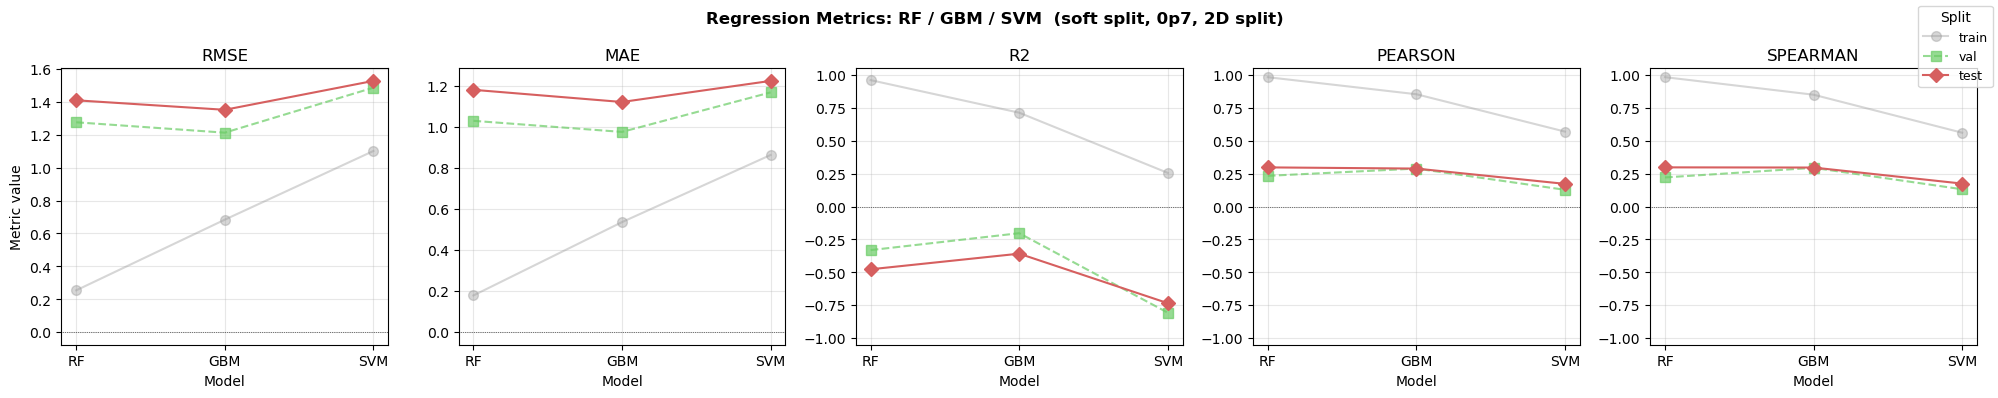

In [12]:
if 'results_df' in dir() and len(results_df) > 0:
    fig, axes = plt.subplots(1, len(METRICS), figsize=(4*len(METRICS), 4))
    split_styles = {'train': ('o', '-', 0.4), 'val': ('s', '--', 0.7), 'test': ('D', '-', 1.0)}
    split_colors = {'train': '#999999', 'val': '#6ACC65', 'test': '#D65F5F'}

    for ax, metric in zip(axes, METRICS):
        for split, (marker, ls, alpha) in split_styles.items():
            sub = results_df[results_df['split'] == split]
            if metric not in sub.columns:
                continue
            ax.plot(
                sub['model'], pd.to_numeric(sub[metric], errors='coerce'),
                marker=marker, linestyle=ls, alpha=alpha,
                color=split_colors[split], label=split, linewidth=1.5, markersize=7
            )
        ax.set_title(metric.upper())
        ax.set_xlabel('Model')
        if metric in ('r2', 'pearson', 'spearman'):
            ax.set_ylim(-1.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.axhline(0, color='black', linewidth=0.5, linestyle=':')

    axes[0].set_ylabel('Metric value')
    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles[:3], labels_leg[:3], loc='upper right', title='Split', fontsize=9)
    fig.suptitle('Regression Metrics: RF / GBM / SVM  (soft split, 0p7, 2D split)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{REPO}/notebooks/figures/regression_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


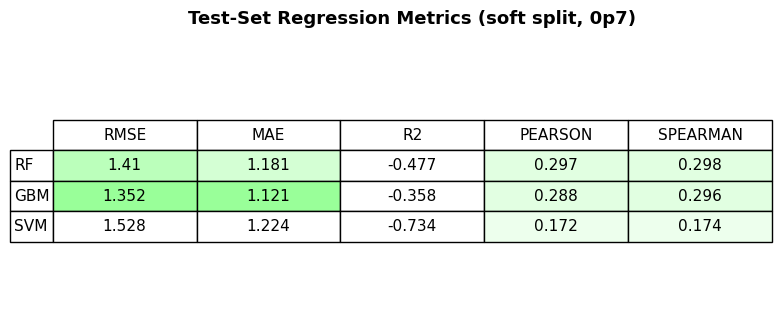


        rmse    mae     r2  pearson  spearman
model                                        
RF     1.410  1.181 -0.477    0.297     0.298
GBM    1.352  1.121 -0.358    0.288     0.296
SVM    1.528  1.224 -0.734    0.172     0.174


In [13]:
if 'results_df' in dir() and len(results_df) > 0:
    test_df = results_df[results_df['split'] == 'test'].set_index('model')
    metric_cols = [m for m in METRICS if m in test_df.columns]
    table = test_df[metric_cols].apply(pd.to_numeric, errors='coerce').round(3)

    fig, ax = plt.subplots(figsize=(len(metric_cols)*1.5 + 1, len(table)*0.6 + 1.5))
    ax.axis('off')
    tbl = ax.table(
        cellText=table.values,
        rowLabels=table.index,
        colLabels=[m.upper() for m in metric_cols],
        cellLoc='center', loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(11)
    tbl.scale(1.4, 1.8)
    for i, model in enumerate(table.index):
        for j, metric in enumerate(metric_cols):
            val = table.loc[model, metric]
            if pd.isna(val):
                continue
            col_vals = pd.to_numeric(table[metric], errors='coerce').dropna()
            if metric in ('r2', 'pearson', 'spearman'):
                intensity = max(0.0, min(1.0, float(val)))
            else:
                rng = col_vals.max() - col_vals.min() + 1e-9
                intensity = 1.0 - float(val - col_vals.min()) / rng
            color = (1 - intensity*0.4, 1.0, 1 - intensity*0.4)
            tbl[(i+1, j)].set_facecolor(color)

    ax.set_title('Test-Set Regression Metrics (soft split, 0p7)', fontsize=13, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(f'{REPO}/notebooks/figures/regression_test_metrics_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()
    print(table.to_string())
